In [1]:
DATA_PATH = "/kaggle/input/datasets/emiliovenegas1/mammography-dataset-from-inbreast-mias-and-ddsm/CLAHE_images"

In [2]:
import osD
NORMAL_PATH = os.path.join(DATA_PATH, "normal")
MALIGNANT_PATH = os.path.join(DATA_PATH, "malignant")

print("Normal count:", len(os.listdir(NORMAL_PATH)))
print("Malignant count:", len(os.listdir(MALIGNANT_PATH)))

Normal count: 2026
Malignant count: 13710


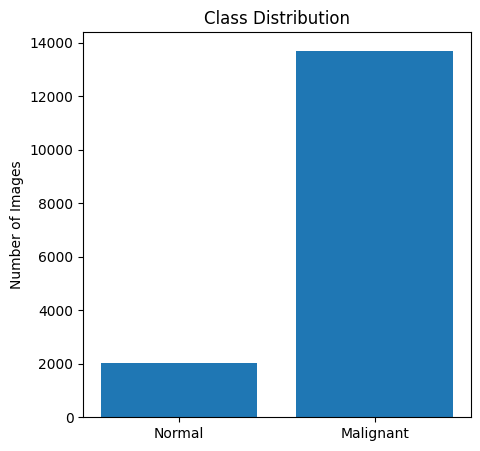

In [3]:
import matplotlib.pyplot as plt

normal_count = len(os.listdir(NORMAL_PATH))
malignant_count = len(os.listdir(MALIGNANT_PATH))

plt.figure(figsize=(5,5))
plt.bar(["Normal", "Malignant"], [normal_count, malignant_count])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_PATH = "/kaggle/input/datasets/emiliovenegas1/mammography-dataset-from-inbreast-mias-and-ddsm/CLAHE_images"

IMG_SIZE = (224,224)
BATCH_SIZE = 16  # Good for P100 GPU

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,      # small rotation (safe for medical)
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=["normal", "malignant"],
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATA_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=["normal", "malignant"],
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

2026-02-22 05:48:01.676230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771739282.063115      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771739282.156709      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771739283.001951      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771739283.001999      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771739283.002003      55 computation_placer.cc:177] computation placer alr

Found 12589 images belonging to 2 classes.
Found 3147 images belonging to 2 classes.
Class indices: {'normal': 0, 'malignant': 1}


In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Extract labels from training generator
y_train = train_generator.classes

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(3.8830968537939543), 1: np.float64(0.5738967906637491)}


In [6]:
print(train_generator.class_indices)

{'normal': 0, 'malignant': 1}


# Efficient Model

## phase 1

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg'
)

base_model.trainable = False  # Freeze backbone

model = keras.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

I0000 00:00:1771739607.632829      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1771739636.893830     186 service.cc:152] XLA service 0x7f08b0003e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771739636.893869     186 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771739639.251473     186 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771739650.750740     186 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


787/787 ━━━━━━━━━━━━━━━━━━━━ 244s 280ms/step - accuracy: 0.4995 - auc: 0.4928 - loss: 0.7756 - precision: 0.8722 - recall: 0.4987 - val_accuracy: 0.8713 - val_auc: 0.7334 - val_loss: 0.3906 - val_precision: 0.8713 - val_recall: 1.0000
Epoch 2/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 162s 205ms/step - accuracy: 0.5260 - auc: 0.5447 - loss: 0.7240 - precision: 0.8900 - recall: 0.5226 - val_accuracy: 0.8780 - val_auc: 0.8190 - val_loss: 0.6407 - val_precision: 0.8935 - val_recall: 0.9763
Epoch 3/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 162s 205ms/step - accuracy: 0.5664 - auc: 0.5426 - loss: 0.7278 - precision: 0.8880 - recall: 0.5759 - val_accuracy: 0.8713 - val_auc: 0.7621 - val_loss: 0.4756 - val_precision: 0.8713 - val_recall: 1.0000
Epoch 4/20
787/787 ━━━━━━━━━━━━━━━━━━━━ 161s 204ms/step - accuracy: 0.5898 - auc: 0.6118 - loss: 0.6878 - precision: 0.9067 - recall: 0.5900 - val_accuracy: 0.8719 - val_auc: 0.7794 - val_loss: 0.5408 - val_precision: 0.8723 - val_recall: 0.9993
Epoch 5/20
787/787 ━━━━━━━━

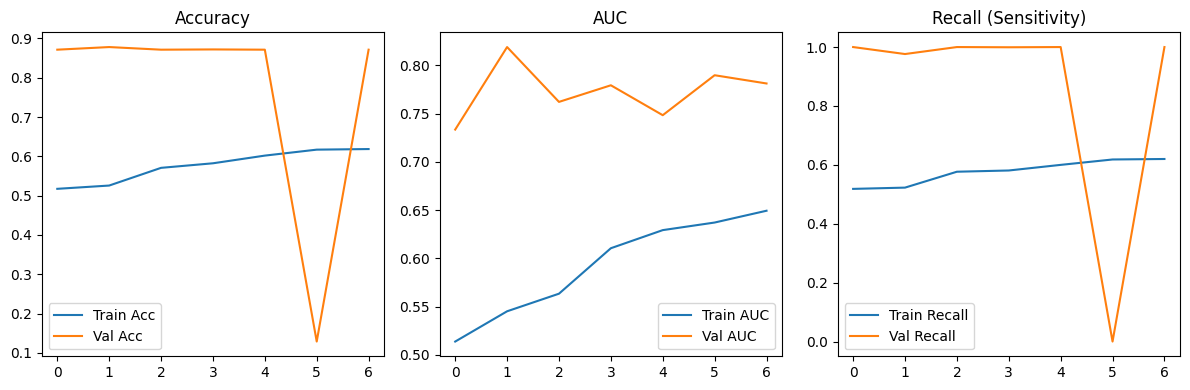

In [12]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history_phase1.history['accuracy'], label='Train Acc')
plt.plot(history_phase1.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# AUC
plt.subplot(1,3,2)
plt.plot(history_phase1.history['auc'], label='Train AUC')
plt.plot(history_phase1.history['val_auc'], label='Val AUC')
plt.legend()
plt.title("AUC")

# Recall
plt.subplot(1,3,3)
plt.plot(history_phase1.history['recall'], label='Train Recall')
plt.plot(history_phase1.history['val_recall'], label='Val Recall')
plt.legend()
plt.title("Recall (Sensitivity)")

plt.tight_layout()
plt.show()

197/197 ━━━━━━━━━━━━━━━━━━━━ 44s 194ms/step


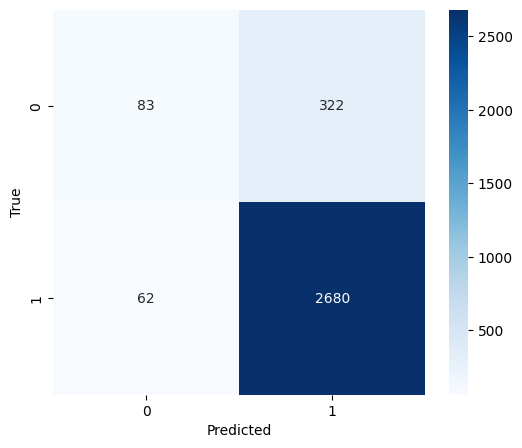

              precision    recall  f1-score   support

           0       0.57      0.20      0.30       405
           1       0.89      0.98      0.93      2742

    accuracy                           0.88      3147
   macro avg       0.73      0.59      0.62      3147
weighted avg       0.85      0.88      0.85      3147



In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred))

In [14]:
import numpy as np
unique, counts = np.unique(val_generator.classes, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(405), np.int32(1): np.int64(2742)}


In [15]:
from sklearn.metrics import roc_curve
import numpy as np

y_pred_prob = model.predict(val_generator).flatten()
y_true = val_generator.classes

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# Youden’s J statistic
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]

print("Best Threshold:", best_threshold)

197/197 ━━━━━━━━━━━━━━━━━━━━ 32s 164ms/step
Best Threshold: 0.52935255


In [16]:
y_pred = (y_pred_prob > best_threshold).astype(int)

197/197 ━━━━━━━━━━━━━━━━━━━━ 33s 165ms/step


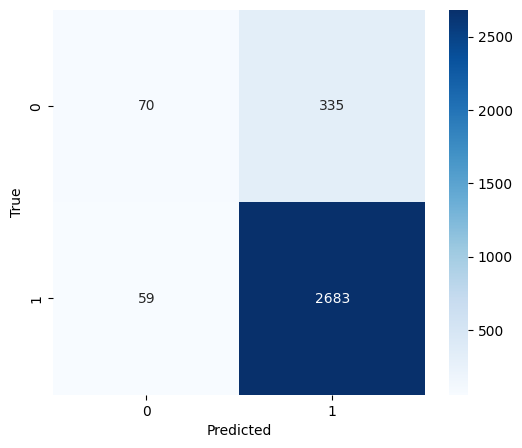

              precision    recall  f1-score   support

           0       0.54      0.17      0.26       405
           1       0.89      0.98      0.93      2742

    accuracy                           0.87      3147
   macro avg       0.72      0.58      0.60      3147
weighted avg       0.84      0.87      0.85      3147



In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred))

In [18]:
model.save("/kaggle/working/efficientnet_phase1.keras")

In [19]:
import pickle

with open("/kaggle/working/history_phase1.pkl", "wb") as f:
    pickle.dump(history_phase1.history, f)

print("Phase 1 model + history saved.")

Phase 1 model + history saved.


In [21]:
!zip -r phase1_model.zip /kaggle/working/efficientnet_phase1.keras

  adding: kaggle/working/efficientnet_phase1.keras (deflated 15%)


In [38]:
from tensorflow import keras

model = keras.models.load_model("/kaggle/working/efficientnet_phase1.keras")

print("Phase 1 model loaded successfully.")

Phase 1 model loaded successfully.


## phase 2


In [39]:
from tensorflow import keras

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,036,200 (19.21 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

 Optimizer params: 657,412 (2.51 MB)

In [40]:
import tensorflow as tf

# Access base model (EfficientNet)
base_model = model.layers[0]

# Unfreeze entire backbone
base_model.trainable = True

# Freeze early layers (keep last 40 trainable)
for layer in base_model.layers[:-40]:
    layer.trainable = False

print("Total layers in base model:", len(base_model.layers))
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total layers in base model: 239
Trainable layers: 40


In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

print("Model recompiled for Phase 2.")

Model recompiled for Phase 2.


In [42]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    mode='max'
)

In [43]:
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10


2026-02-22 06:48:42.230369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:48:42.436000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:48:42.714378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:48:42.919895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


580/787 ━━━━━━━━━━━━━━━━━━━━ 37s 182ms/step - accuracy: 0.5083 - auc: 0.5153 - loss: 0.9072 - precision: 0.8778 - recall: 0.5072

2026-02-22 06:50:42.431131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:50:42.636528: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:50:42.906493: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-22 06:50:43.111927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


787/787 ━━━━━━━━━━━━━━━━━━━━ 234s 259ms/step - accuracy: 0.5102 - auc: 0.5161 - loss: 0.9038 - precision: 0.8772 - recall: 0.5098 - val_accuracy: 0.1287 - val_auc: 0.8402 - val_loss: 1.1450 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/10
787/787 ━━━━━━━━━━━━━━━━━━━━ 165s 210ms/step - accuracy: 0.5313 - auc: 0.5454 - loss: 0.8459 - precision: 0.8904 - recall: 0.5262 - val_accuracy: 0.1287 - val_auc: 0.8982 - val_loss: 1.5576 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/10
787/787 ━━━━━━━━━━━━━━━━━━━━ 165s 209ms/step - accuracy: 0.5314 - auc: 0.5532 - loss: 0.8420 - precision: 0.8920 - recall: 0.5247 - val_accuracy: 0.1287 - val_auc: 0.9016 - val_loss: 1.7141 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 4/10
787/787 ━━━━━━━━━━━━━━━━━━━━ 166s 211ms/step - accuracy: 0.5571 - auc: 0.5945 - loss: 0.8116 - precision: 0.9035 - recall: 0.5483 - val_accuracy: 0.1287 -

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(val_generator).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

197/197 ━━━━━━━━━━━━━━━━━━━━ 44s 193ms/step
Confusion Matrix:
[[ 405    0]
 [2742    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.13      1.00      0.23       405
           1       0.00      0.00      0.00      2742

    accuracy                           0.13      3147
   macro avg       0.06      0.50      0.11      3147
weighted avg       0.02      0.13      0.03      3147



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
import numpy as np

# Get probabilities
y_pred_prob = model.predict(val_generator).flatten()

# True labels
y_true = val_generator.classes

print("Predictions shape:", y_pred_prob.shape)

197/197 ━━━━━━━━━━━━━━━━━━━━ 32s 162ms/step
Predictions shape: (3147,)


In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# Youden’s J statistic
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.021421181


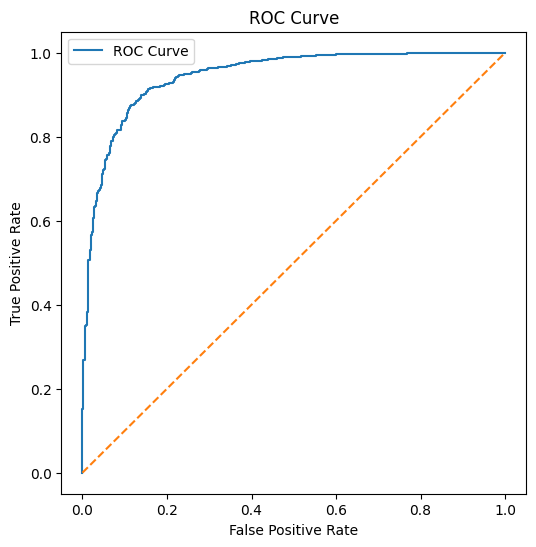

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

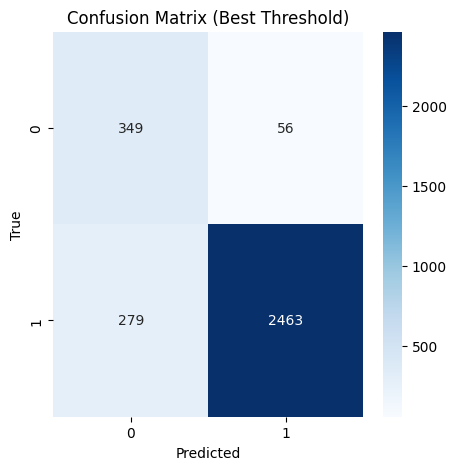

Confusion Matrix:
 [[ 349   56]
 [ 279 2463]]

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.86      0.68       405
           1       0.98      0.90      0.94      2742

    accuracy                           0.89      3147
   macro avg       0.77      0.88      0.81      3147
weighted avg       0.92      0.89      0.90      3147



In [48]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Apply best threshold
y_pred = (y_pred_prob > best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Best Threshold)")
plt.show()

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

In [49]:
model.save("/kaggle/working/efficientnet_phase2.keras")
print("Phase 2 model saved successfully.")

Phase 2 model saved successfully.


In [50]:
model.save_weights("/kaggle/working/phase2_weights.weights.h5")

In [51]:
import pickle

with open("/kaggle/working/history_phase2.pkl", "wb") as f:
    pickle.dump(history_phase2.history, f)

print("History saved.")

History saved.


In [52]:
!zip -r phase2_full_package.zip \
    /kaggle/working/efficientnet_phase2.keras \
    /kaggle/working/phase2_weights.weights.h5 \
    /kaggle/working/history_phase2.pkl

  adding: kaggle/working/efficientnet_phase2.keras (deflated 9%)
  adding: kaggle/working/phase2_weights.weights.h5 (deflated 9%)
  adding: kaggle/working/history_phase2.pkl (deflated 57%)


# Densenet model 

## phase 1

In [55]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf

In [56]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg'
)

base_model.trainable = False  # Phase 1

model_dense = keras.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_dense.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model_dense.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [57]:
import tensorflow.keras.backend as K

def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = K.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        alpha_factor = y_true*alpha + (1-y_true)*(1-alpha)
        modulating_factor = K.pow((1-p_t), gamma)
        return K.mean(alpha_factor * modulating_factor * bce)
    return loss

In [63]:
model_dense.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(alpha=0.75, gamma=2),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

In [64]:
history_dense_phase1 = model_dense.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1,
    class_weight=class_weight_dict,  # keep this even with focal loss
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            restore_best_weights=True,
            mode='max'
        )
    ]
)

Epoch 1/15
787/787 ━━━━━━━━━━━━━━━━━━━━ 247s 280ms/step - accuracy: 0.7067 - auc: 0.8674 - loss: 0.2025 - precision: 0.9679 - recall: 0.6814 - val_accuracy: 0.9793 - val_auc: 0.9997 - val_loss: 0.0137 - val_precision: 1.0000 - val_recall: 0.9763
Epoch 2/15
787/787 ━━━━━━━━━━━━━━━━━━━━ 165s 209ms/step - accuracy: 0.9232 - auc: 0.9914 - loss: 0.0342 - precision: 0.9964 - recall: 0.9151 - val_accuracy: 0.9965 - val_auc: 1.0000 - val_loss: 0.0037 - val_precision: 1.0000 - val_recall: 0.9960
Epoch 3/15
787/787 ━━━━━━━━━━━━━━━━━━━━ 162s 206ms/step - accuracy: 0.9693 - auc: 0.9957 - loss: 0.0120 - precision: 0.9955 - recall: 0.9692 - val_accuracy: 0.9962 - val_auc: 0.9999 - val_loss: 0.0020 - val_precision: 1.0000 - val_recall: 0.9956
Epoch 4/15
787/787 ━━━━━━━━━━━━━━━━━━━━ 163s 207ms/step - accuracy: 0.9842 - auc: 0.9974 - loss: 0.0064 - precision: 0.9949 - recall: 0.9869 - val_accuracy: 0.9971 - val_auc: 1.0000 - val_loss: 0.0017 - val_precision: 1.0000 - val_recall: 0.9967
Epoch 5/15
787/7

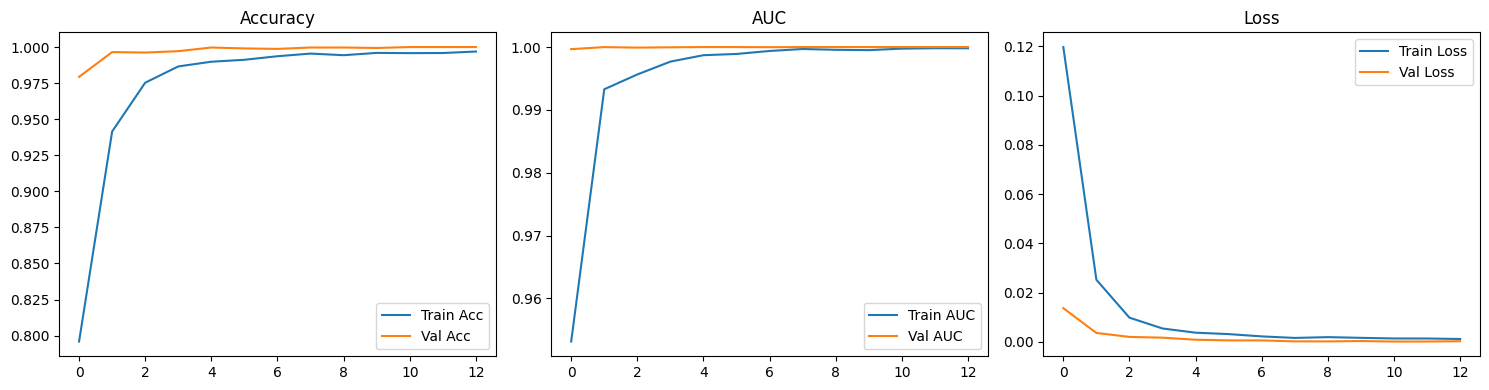

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# Accuracy
plt.subplot(1,3,1)
plt.plot(history_dense_phase1.history['accuracy'], label='Train Acc')
plt.plot(history_dense_phase1.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

# AUC
plt.subplot(1,3,2)
plt.plot(history_dense_phase1.history['auc'], label='Train AUC')
plt.plot(history_dense_phase1.history['val_auc'], label='Val AUC')
plt.title("AUC")
plt.legend()

# Loss
plt.subplot(1,3,3)
plt.plot(history_dense_phase1.history['loss'], label='Train Loss')
plt.plot(history_dense_phase1.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [66]:
import numpy as np

y_pred_prob = model_dense.predict(val_generator).flatten()
y_true = val_generator.classes

print("Prediction shape:", y_pred_prob.shape)

197/197 ━━━━━━━━━━━━━━━━━━━━ 60s 245ms/step
Prediction shape: (3147,)


Best Threshold: 0.6406048


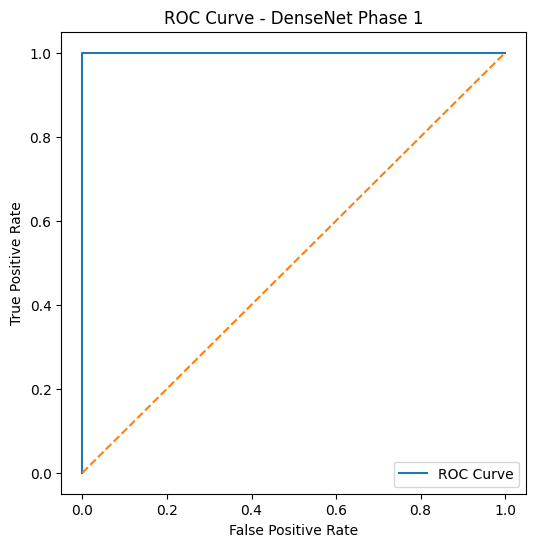

In [67]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# Youden’s J
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet Phase 1")
plt.legend()
plt.show()

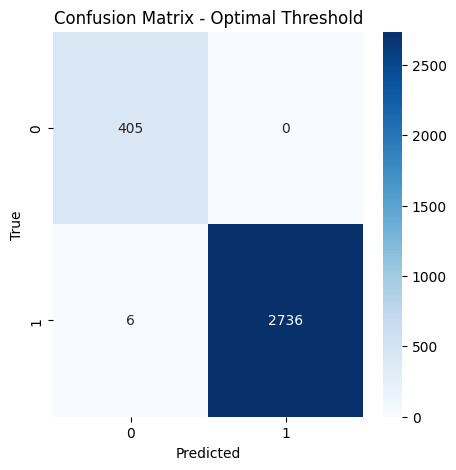

Confusion Matrix:
 [[ 405    0]
 [   6 2736]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       405
           1       1.00      1.00      1.00      2742

    accuracy                           1.00      3147
   macro avg       0.99      1.00      1.00      3147
weighted avg       1.00      1.00      1.00      3147



In [68]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (y_pred_prob > best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Optimal Threshold")
plt.show()

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

In [71]:
import os
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/emiliovenegas1/mammography-dataset-from-inbreast-mias-and-ddsm/CLAHE_images"

classes = ["normal", "malignant"]

image_paths = []
labels = []

for label in classes:
    folder = os.path.join(DATA_PATH, label)
    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label)

df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 15736


,filepath,label
0,/kaggle/input/datasets/emiliovenegas1/mammogra...,normal
1,/kaggle/input/datasets/emiliovenegas1/mammogra...,normal
2,/kaggle/input/datasets/emiliovenegas1/mammogra...,normal
3,/kaggle/input/datasets/emiliovenegas1/mammogra...,normal
4,/kaggle/input/datasets/emiliovenegas1/mammogra...,normal


In [72]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

Train size: 12588
Validation size: 3148

Train class distribution:
label
malignant    10967
normal        1621
Name: count, dtype: int64

Validation class distribution:
label
malignant    2743
normal        405
Name: count, dtype: int64


## ImageDataGenerators 2

In [73]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 12588 validated image filenames belonging to 2 classes.
Found 3148 validated image filenames belonging to 2 classes.
Class indices: {'malignant': 0, 'normal': 1}


In [74]:
print(train_df["label"].value_counts())

label
malignant    10967
normal        1621
Name: count, dtype: int64


## Oversample Normal Class

In [75]:
from sklearn.utils import resample
import pandas as pd

# Separate classes
normal_df = train_df[train_df["label"] == "normal"]
malignant_df = train_df[train_df["label"] == "malignant"]

# Upsample normal to match malignant
normal_upsampled = resample(
    normal_df,
    replace=True,
    n_samples=len(malignant_df),
    random_state=42
)

# Combine
balanced_train_df = pd.concat([malignant_df, normal_upsampled])

# Shuffle
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_train_df["label"].value_counts())

label
normal       10967
malignant    10967
Name: count, dtype: int64


In [76]:
train_generator = train_datagen.flow_from_dataframe(
    balanced_train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 21934 validated image filenames belonging to 2 classes.


### Training again by handling imbalance data with Oversampling via Data Augmentation

In [77]:
history_dense_phase1 = model_dense.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=5,
            restore_best_weights=True,
            mode='max'
        )
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
686/686 ━━━━━━━━━━━━━━━━━━━━ 285s 384ms/step - accuracy: 0.8115 - auc: 0.8821 - loss: 0.1478 - precision: 0.7549 - recall: 0.9613 - val_accuracy: 0.9854 - val_auc: 0.9999 - val_loss: 0.0030 - val_precision: 0.8998 - val_recall: 0.9975
Epoch 2/15
686/686 ━━━━━━━━━━━━━━━━━━━━ 232s 339ms/step - accuracy: 0.9839 - auc: 0.9995 - loss: 0.0040 - precision: 0.9709 - recall: 0.9973 - val_accuracy: 0.9936 - val_auc: 0.9999 - val_loss: 0.0015 - val_precision: 0.9551 - val_recall: 0.9975
Epoch 3/15
686/686 ━━━━━━━━━━━━━━━━━━━━ 235s 342ms/step - accuracy: 0.9914 - auc: 0.9998 - loss: 0.0022 - precision: 0.9857 - recall: 0.9972 - val_accuracy: 0.9962 - val_auc: 0.9999 - val_loss: 0.0010 - val_precision: 0.9735 - val_recall: 0.9975
Epoch 4/15
686/686 ━━━━━━━━━━━━━━━━━━━━ 237s 346ms/step - accuracy: 0.9927 - auc: 0.9998 - loss: 0.0020 - precision: 0.9873 - recall: 0.9979 - val_accuracy: 0.9981 - val_auc: 1.0000 - val_loss: 3.7831e-04 - val_precision: 0.9878 - val_recall: 0.9975
Epoch 5/15
6

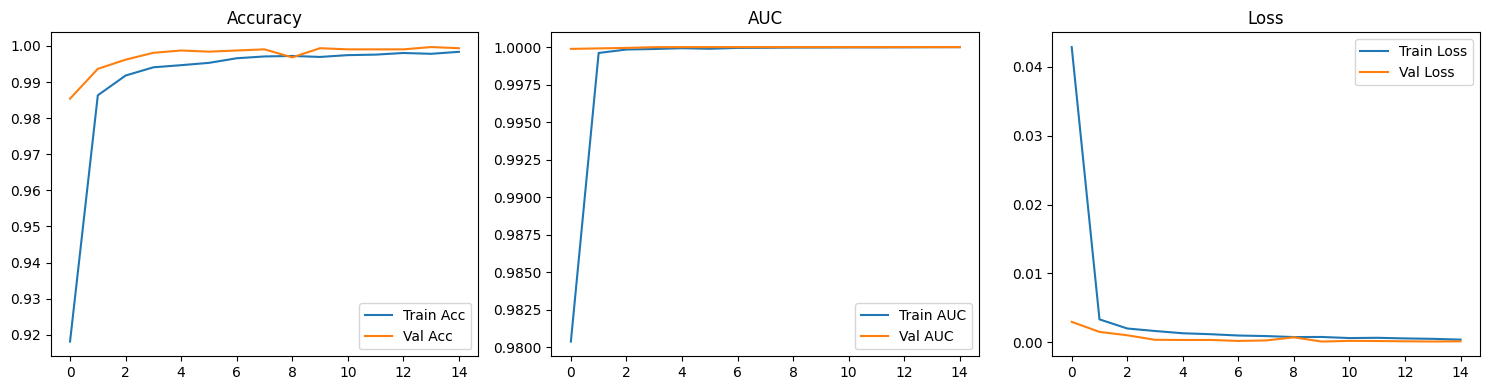

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# Accuracy
plt.subplot(1,3,1)
plt.plot(history_dense_phase1.history['accuracy'], label='Train Acc')
plt.plot(history_dense_phase1.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

# AUC
plt.subplot(1,3,2)
plt.plot(history_dense_phase1.history['auc'], label='Train AUC')
plt.plot(history_dense_phase1.history['val_auc'], label='Val AUC')
plt.title("AUC")
plt.legend()

# Loss
plt.subplot(1,3,3)
plt.plot(history_dense_phase1.history['loss'], label='Train Loss')
plt.plot(history_dense_phase1.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [79]:
import numpy as np

y_pred_prob = model_dense.predict(val_generator).flatten()
y_true = val_generator.classes

print("Predictions shape:", y_pred_prob.shape)

99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step
Predictions shape: (3148,)


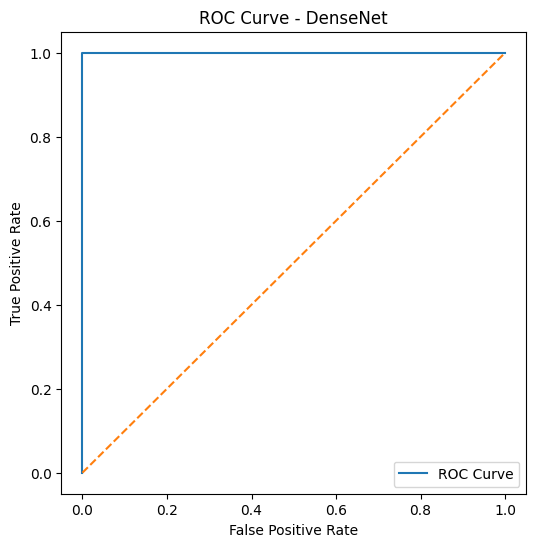

In [80]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet")
plt.legend()
plt.show()

In [81]:
import numpy as np

j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.7526994


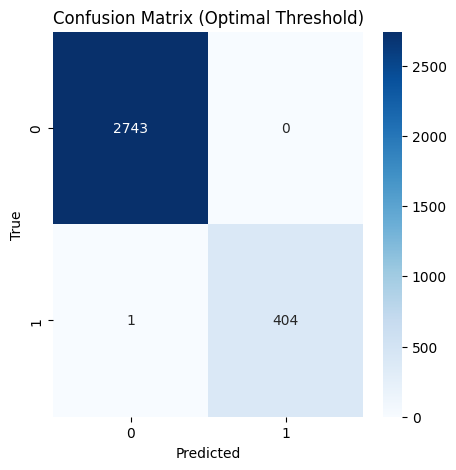

Confusion Matrix:
 [[2743    0]
 [   1  404]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2743
           1       1.00      1.00      1.00       405

    accuracy                           1.00      3148
   macro avg       1.00      1.00      1.00      3148
weighted avg       1.00      1.00      1.00      3148



In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (y_pred_prob > best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Optimal Threshold)")
plt.show()

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

In [83]:
!zip -r densenet_phase1_package.zip \
    /kaggle/working/densenet_phase1.keras \
    /kaggle/working/history_densenet_phase1.pkl

	zip warning: name not matched: /kaggle/working/densenet_phase1.keras
	zip warning: name not matched: /kaggle/working/history_densenet_phase1.pkl

zip error: Nothing to do! (try: zip -r densenet_phase1_package.zip . -i /kaggle/working/densenet_phase1.keras /kaggle/working/history_densenet_phase1.pkl)
